# main1 resultsThe 9 PDE runs of `pde_setup1.jld2`: 3 SI systems x p = 0.01, 0.1, 1.0, all from `main1()` in`base.jl`. The well-mixed steady states they were perturbed around live in `test1.jld2`,indexed by `df_row`.Writes four pdfs into `main1/`, each one kind of plot with a panel per run:`spacetime_biomass.pdf`, `spacetime_dominant.pdf`, `final_states.pdf`, `final_vs_hom.pdf`.

In [1]:
]activate ../../../

  Activating project at `~/UCLOneDrive/SpatialStructureInMicrobialCommunities/SSMCCode`


In [2]:
using Revise
includet("./base.jl")

In [3]:
using GLMakie
using CairoMakie
CairoMakie.activate!()
using Statistics, ColorSchemes

## The runs

In [4]:
outdir = "main1"
smd = load("pde_setup1.jld2", "metadata")
setup_df = load("pde_setup1.jld2", "pde_df")
df = collect_pde_runs(outdir)

ode_df = load("test1.jld2", "df")   # df_row indexes into this
hss_of(r) = ode_df.final_states[r.df_row]
# the setup was built off this same ode df, check the systems still line up
@assert all(ode_df.params[r.df_row].c == setup_df.params[r.pde_df_row].c for r in eachrow(df))

Ns, Nr = get_Ns(setup_df.params[1])
T = df.T[1]

@printf("%d runs, retcodes: %s\n", nrow(df), string(unique(string.(df.retcode))))
@printf("all reached T = %.3g: %s,  worst residual %.3g\n",
    T, all(df.final_T .== T), maximum(df.maxresid))
@printf("saved states per run: %d - %d\n", minimum(df.num_saved), maximum(df.num_saved))

select(df, Not(:final_state))

9 runs, retcodes: ["Success"]
all reached T = 1e+08: true,  worst residual 9.29e-09


saved states per run: 25 - 91


Row,pde_df_row,gdf_row,df_row,p,L,sN,T,retcode,final_T,maxresid,num_saved,realtime
,Int64,Int64,Int64,Float64,Float64,Int64,Float64,T,Float64,Float64,Int64,Float64
1,1,1,9,0.01,4.07461,2500,1.0e8,Success,1.0e8,1.73008e-10,25,4714.6
2,2,1,9,0.1,4.07461,2500,1.0e8,Success,1.0e8,6.22066e-10,33,6512.52
3,3,1,9,1.0,4.07461,2500,1.0e8,Success,1.0e8,6.46995e-10,32,6142.91
4,4,2,18,0.01,4.16957,2500,1.0e8,Success,1.0e8,3.1298e-10,28,5741.07
5,5,2,18,0.1,4.16957,2500,1.0e8,Success,1.0e8,6.40334e-10,33,6332.36
6,6,2,18,1.0,4.16957,2500,1.0e8,Success,1.0e8,9.29367e-9,36,7598.02
7,7,3,16,0.01,2.95132,2500,1.0e8,Success,1.0e8,6.07287e-10,91,9923.16
8,8,3,16,0.1,2.95132,2500,1.0e8,Success,1.0e8,1.17897e-9,31,5596.27
9,9,3,16,1.0,2.95132,2500,1.0e8,Success,1.0e8,6.94346e-10,27,4343.5


In [8]:
# panel grid: one row per p, one column per system
ps = smd.ps
sys = sort(unique(df.gdf_row))
np, nsys = length(ps), length(sys)
panel_pos(r) = (findfirst(==(r.p), ps), findfirst(==(r.gdf_row), sys))

short_title(r) = @sprintf("sys %d (df %d), p = %g, L = %.3g", r.gdf_row, r.df_row, r.p, r.L)
suptitle = @sprintf("K = %g, l = %g, N = M = %d, DN = %g, DI = %g, sN = %d, T = %.3g",
    smd.K, smd.l, Ns, smd.DN, smd.DI, smd.sN, T)

xs_of(r) = ((1:r.sN) .- 0.5) ./ r.sN   # x / L

# the t window every space-time panel is drawn over. The solver saves a couple of
# states at t ~ 1e-17, so without a floor here 20 empty decades take up most of a
# log axis. Nothing moves before t ~ 1.
trange = (1e0, T)
suptitle

"K = 30, l = 0.999, N = M = 20, DN = 1e-06, DI = 1, sN = 2500, T = 1e+08"

## Reduced fields for the space-time plotsOne pass over the saved states (~270MB on disk), keeping only the two scalar fields thekymographs need: total strain biomass and which strain is locally largest.

In [9]:
"""
Cell edges for a heatmap on a log time axis. Makie extrapolates half a cell past
each end, which on these solver time grids lands at or below zero and makes log10
throw; bisecting in log space instead keeps every edge positive.
"""
function log_edges(ts)
    lt = log10.(ts)
    mid = (lt[1:end-1] .+ lt[2:end]) ./ 2
    10 .^ vcat(2 * lt[1] - mid[1], mid, 2 * lt[end] - mid[end])
end

"""
The saved states of `s` inside `trange` as `(; keep, edges)`. The outermost cells
are stretched to the window edges so every panel fills the same axis - outside
them the state is either the untouched initial condition or the final one.
"""
function window(s, trange)
    keep = findall(t -> trange[1] <= t <= trange[2], s.ts)
    edges = log_edges(s.ts[keep])
    edges[1], edges[end] = trange
    (; keep, edges)
end

series = Dict(map(eachrow(df)) do r
    (; ts, us) = load_pde_states(outdir, r.pde_df_row)
    keep = findall(>(0.0), ts)   # t = 0 has no place on a log axis
    ts, us = ts[keep], us[keep]
    ntot = permutedims(reduce(hcat, [vec(sum(view(u, 1:Ns, :), dims=1)) for u in us]))
    dom = permutedims(reduce(hcat, [[argmax(view(u, 1:Ns, x)) for x in axes(u, 2)] for u in us]))
    r.pde_df_row => (; ts, ntot, dom)
end)

# saved states falling inside trange, per run
[length(window(series[r.pde_df_row], trange).keep) for r in eachrow(df)]

9-element Vector{Int64}:
 22
 30
 29
 25
 30
 33
 88
 28
 24

## 1. Space-time, total strain biomass

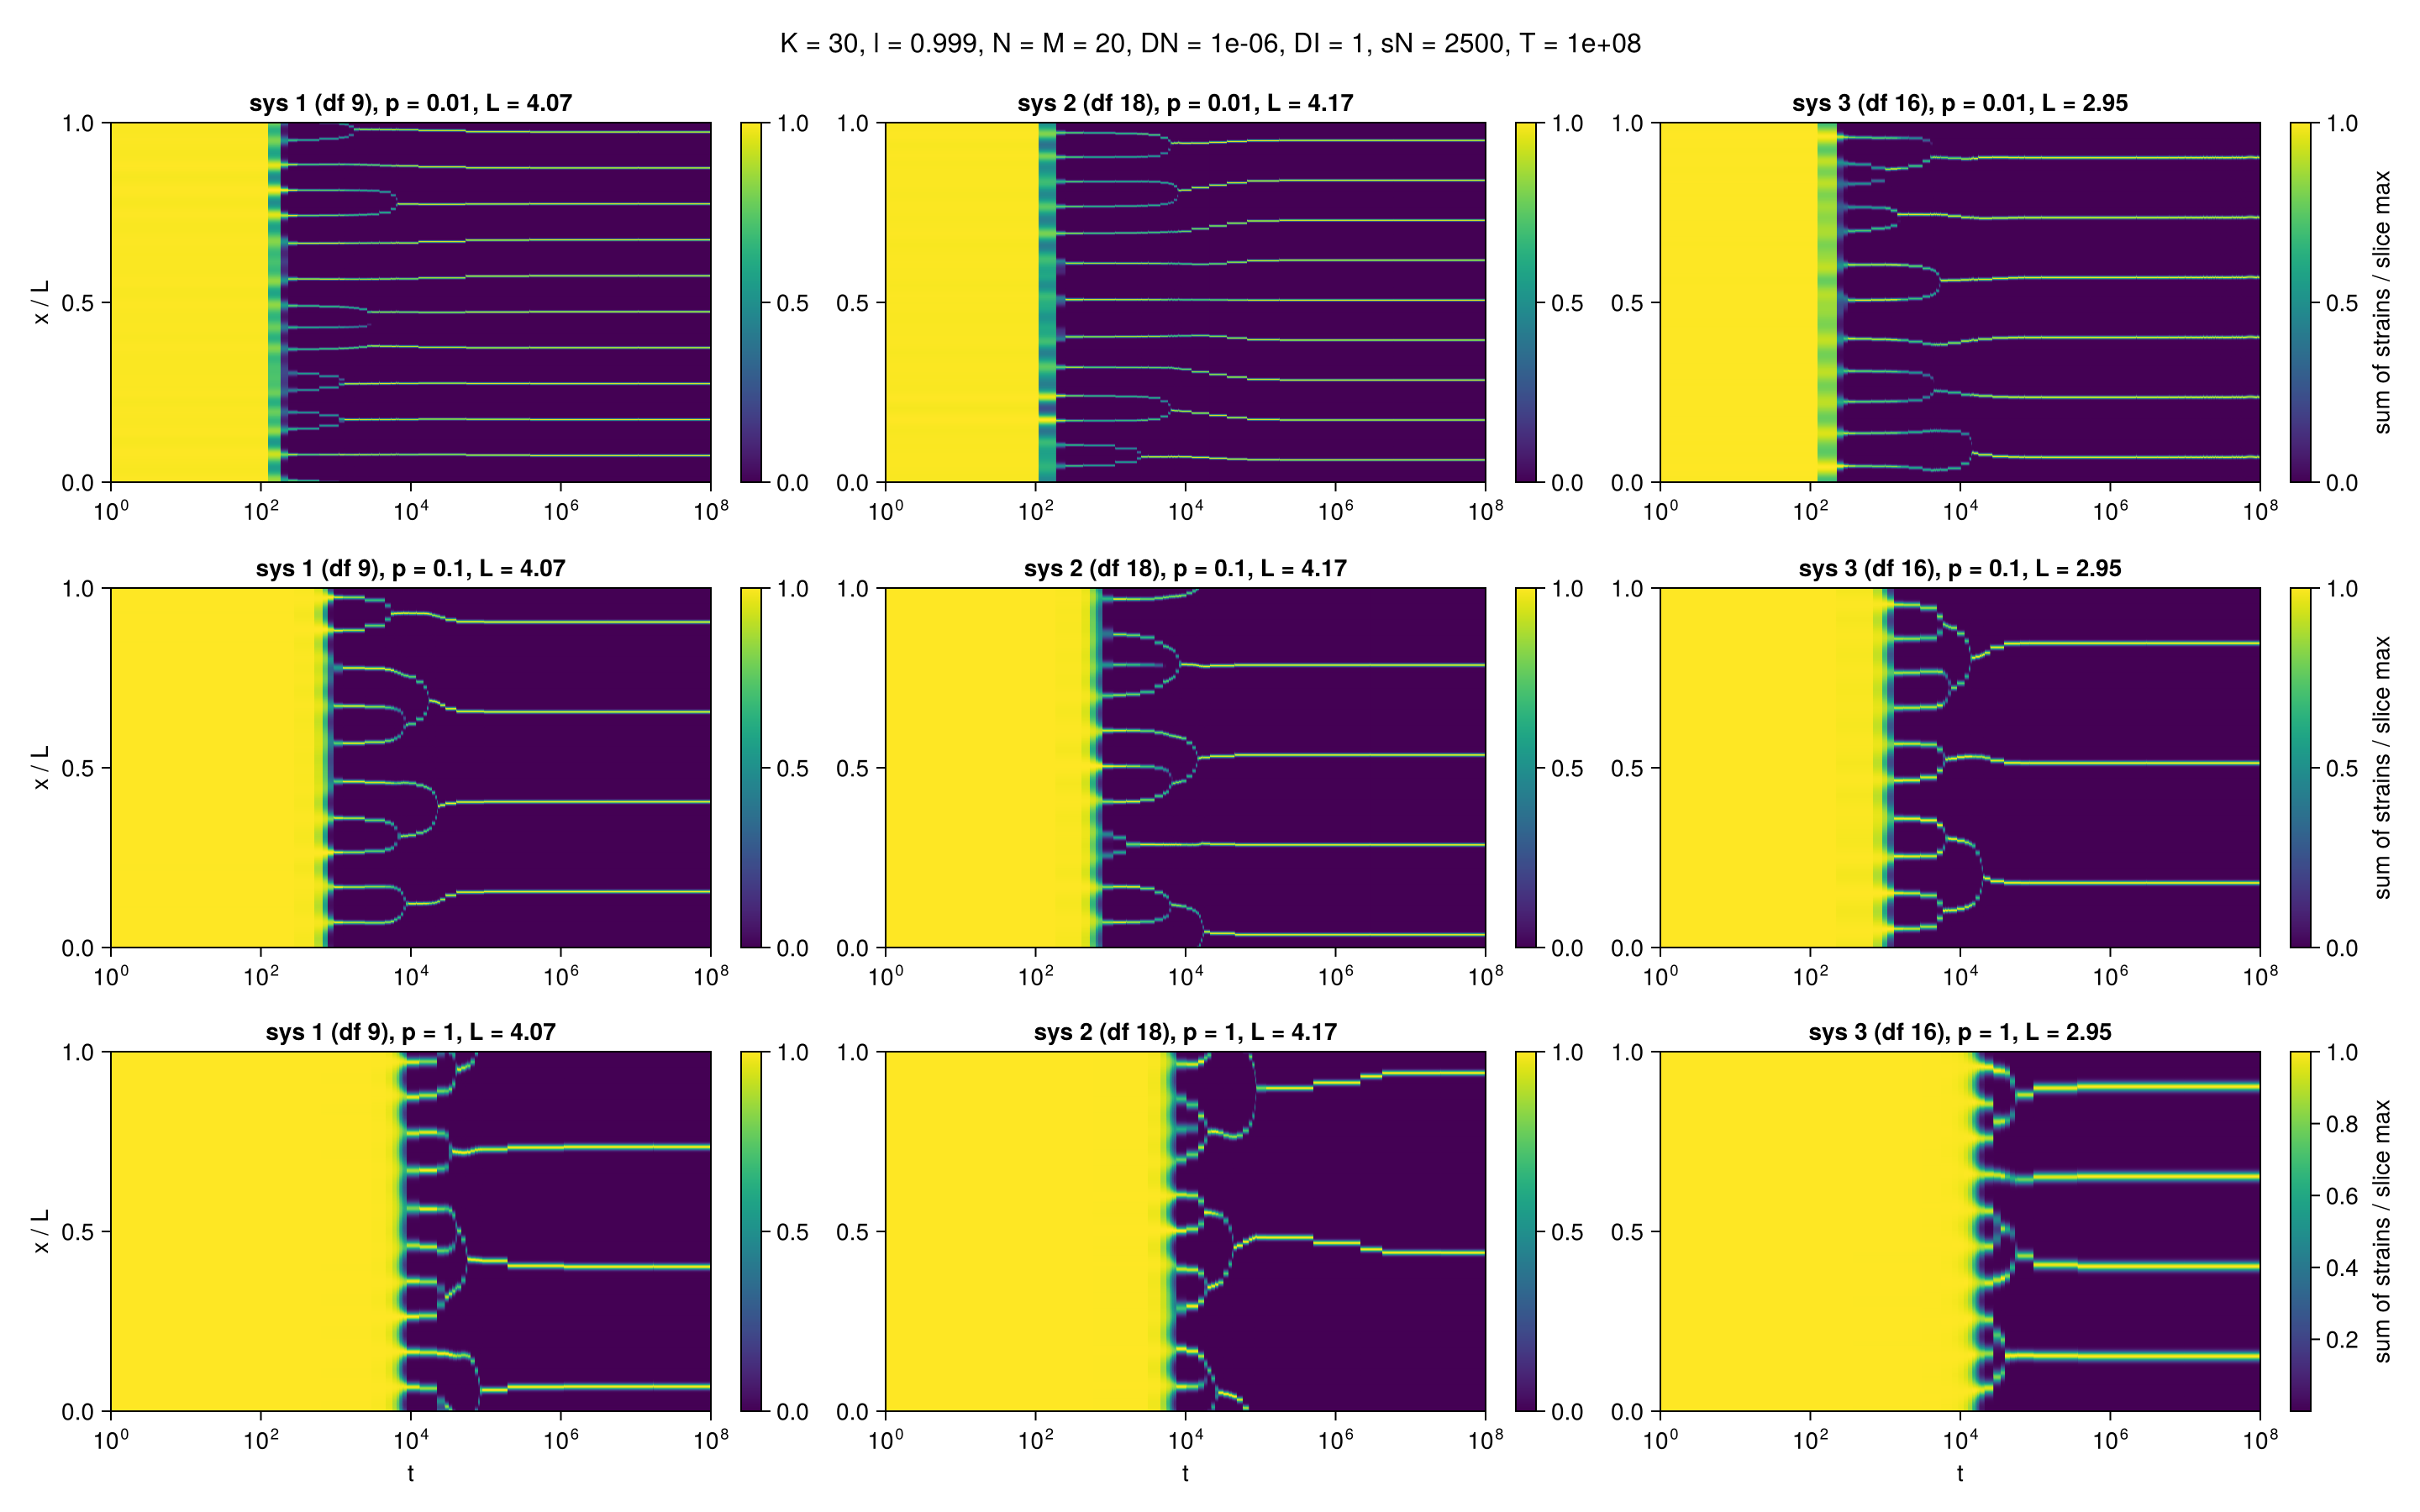

In [10]:
# Each time slice divided by its own maximum. The spikes reach ~600 on a
# homogeneous background of ~10, so on a raw scale the whole emergence phase is
# one flat colour; per-slice normalisation shows the pattern's shape at every
# stage and says nothing about amplitude. Set false for raw values.
norm_slices = true

fig = Figure(; size=(480 * nsys, 300 * np))
Label(fig[0, 1:nsys], suptitle; fontsize=16, tellwidth=false)

for r in eachrow(df)
    i, j = panel_pos(r)
    gl = GridLayout(fig[i, j])
    ax = Axis(gl[1, 1]; xscale=log10, title=short_title(r),
        xlabel=(i == np ? "t" : ""), ylabel=(j == 1 ? "x / L" : ""))

    s = series[r.pde_df_row]
    (; keep, edges) = window(s, trange)
    z = s.ntot[keep, :]
    norm_slices && (z = z ./ maximum(z; dims=2))

    hm = heatmap!(ax, edges, xs_of(r), z; colormap=:viridis, rasterize=2)
    Colorbar(gl[1, 2], hm;
        label=(j == nsys ? (norm_slices ? "sum of strains / slice max" : "sum of strains") : ""))
    xlims!(ax, trange...)
end

Makie.save(joinpath(outdir, "spacetime_biomass.pdf"), fig)
fig

## 2. Space-time, locally dominant strain`argmax` over the strains at each gridpoint, tab20 so each of the 20 strains keeps one colour.Says nothing about amplitude.

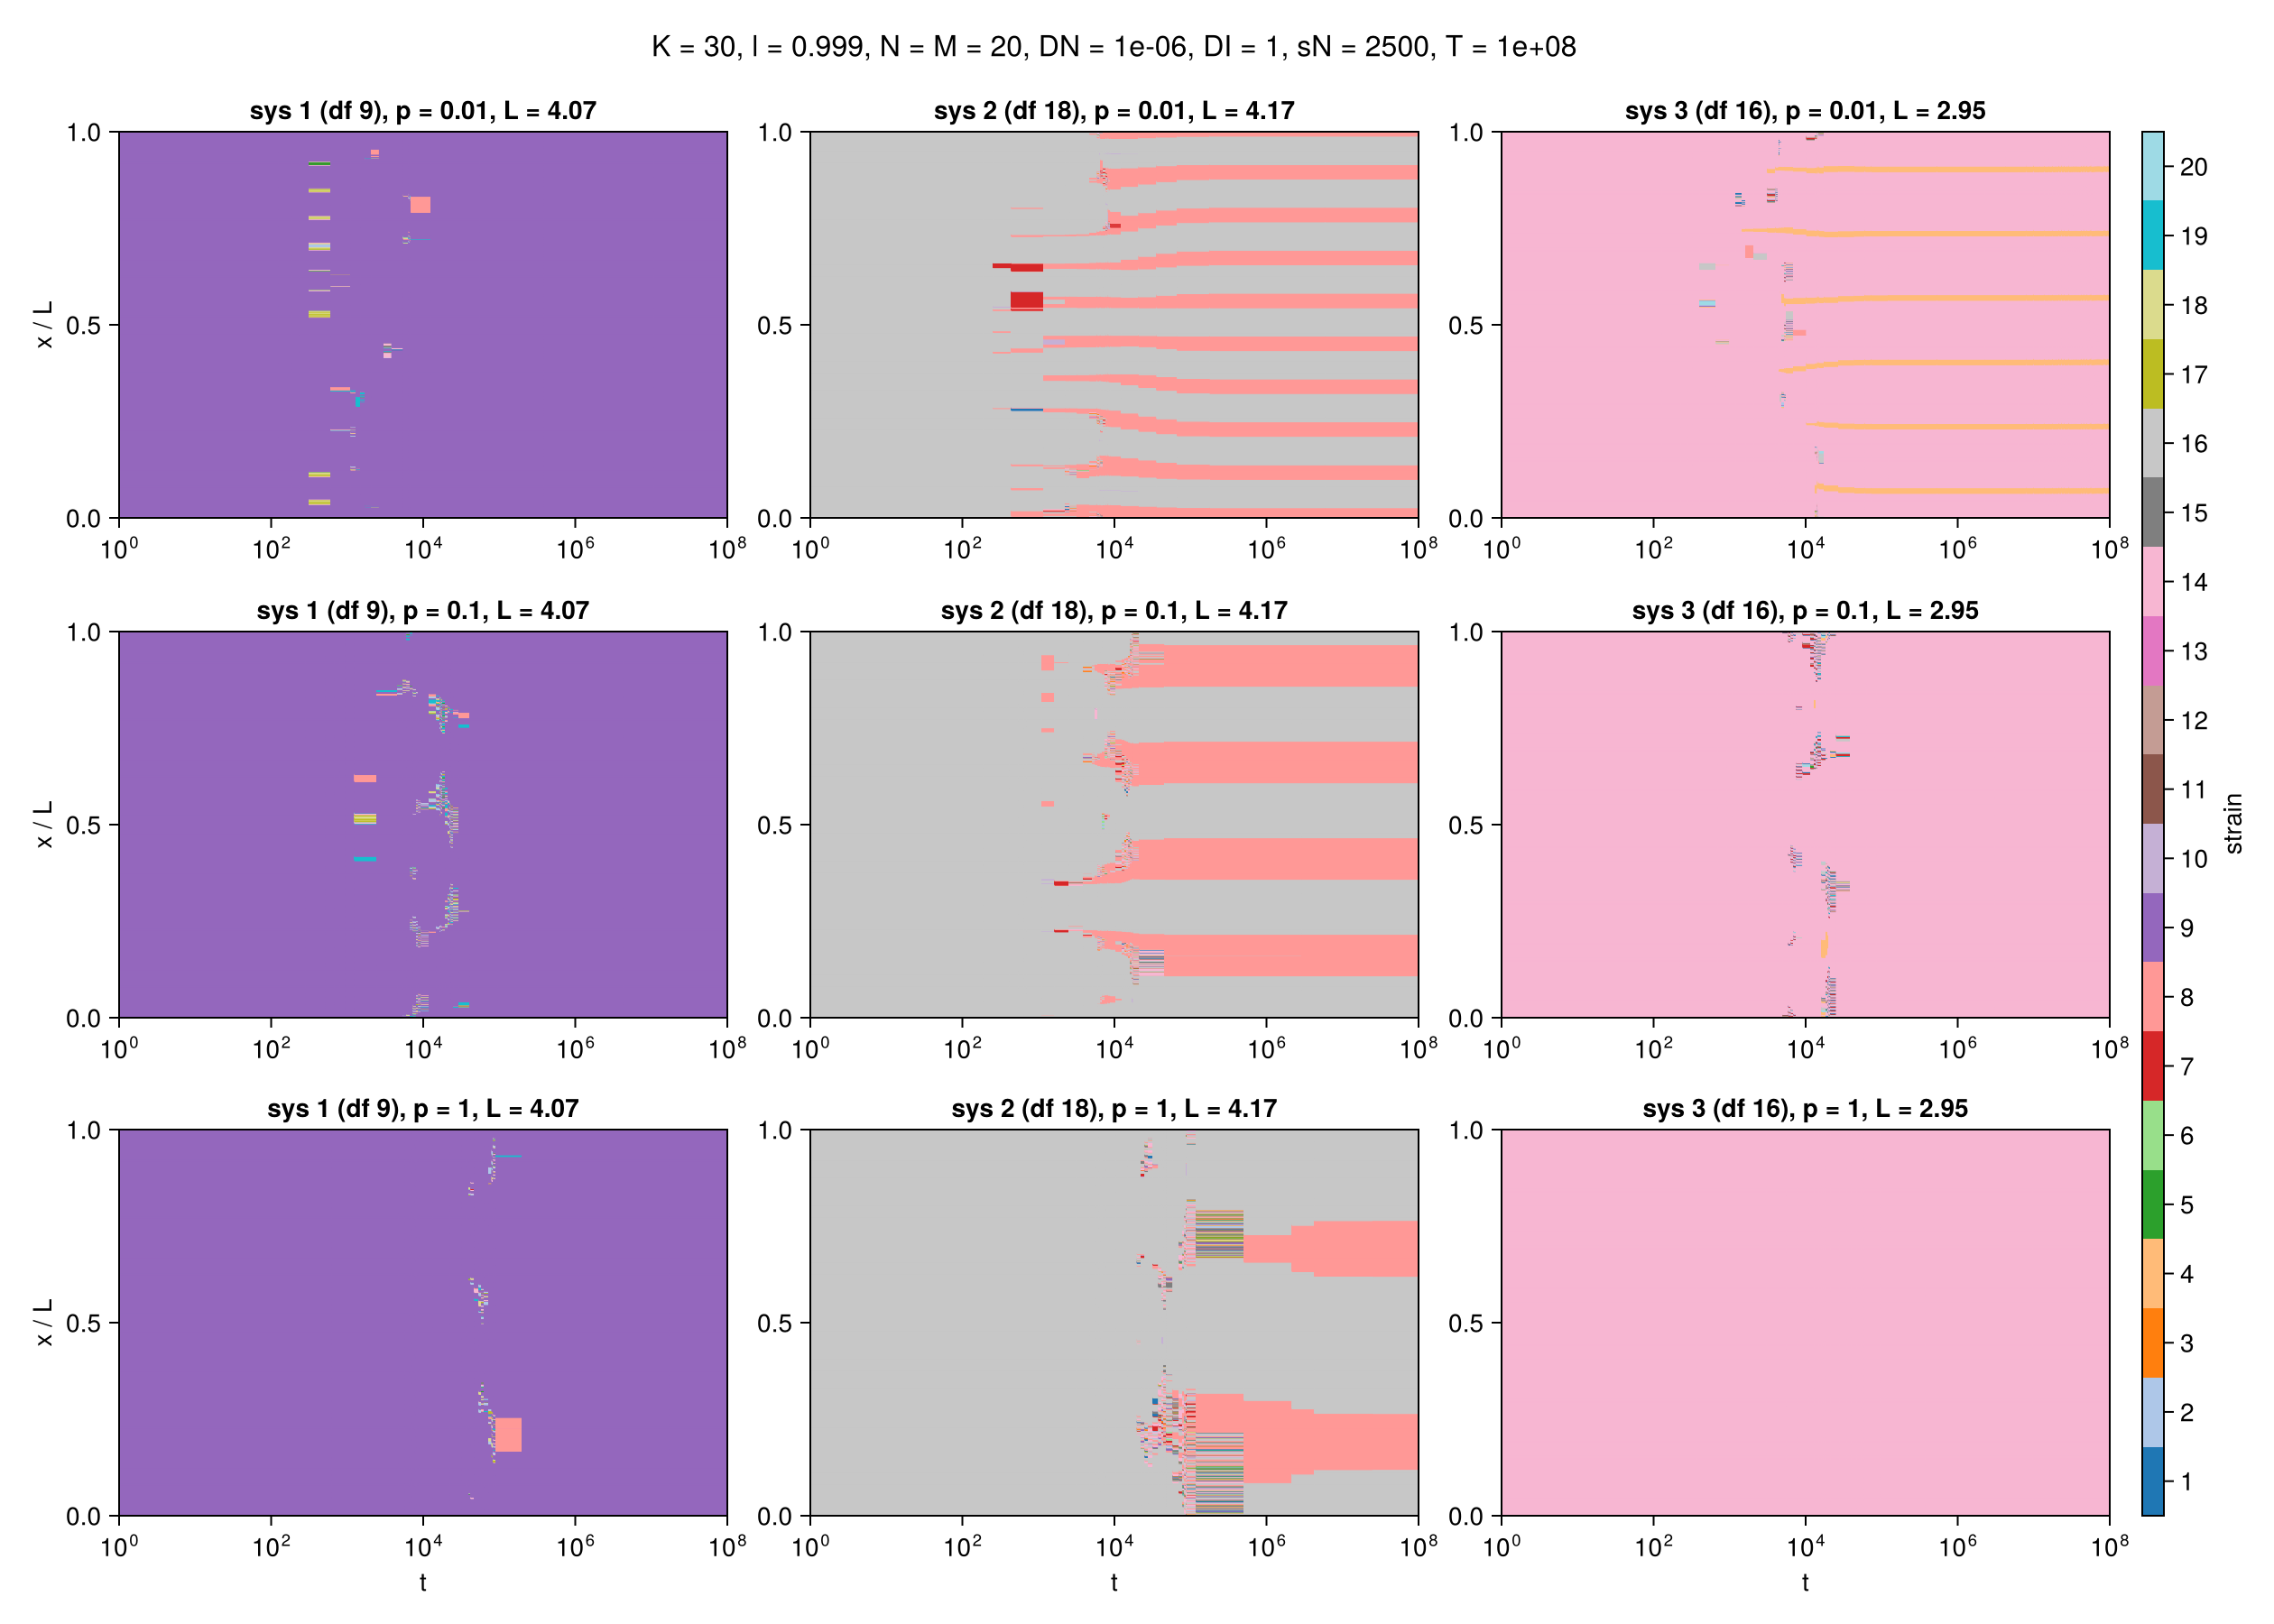

In [13]:
strain_cmap = cgrad(ColorSchemes.tab20, Ns; categorical=true)
strain_crange = (0.5, Ns + 0.5)

fig = Figure(; size=(420 * nsys, 300 * np))
Label(fig[0, 1:nsys], suptitle; fontsize=16, tellwidth=false)

for r in eachrow(df)
    i, j = panel_pos(r)
    ax = Axis(fig[i, j]; xscale=log10, title=short_title(r),
        xlabel=(i == np ? "t" : ""), ylabel=(j == 1 ? "x / L" : ""))

    s = series[r.pde_df_row]
    (; keep, edges) = window(s, trange)

    heatmap!(ax, edges, xs_of(r), s.dom[keep, :];
        colormap=strain_cmap, colorrange=strain_crange, rasterize=2)
    xlims!(ax, trange...)
end
Colorbar(fig[1:np, nsys+1]; colormap=strain_cmap, colorrange=strain_crange,
    label="strain", ticks=1:Ns)

Makie.save(joinpath(outdir, "spacetime_dominant.pdf"), fig)
fig

## 3. Final statesStrains on top, resources below, dashed lines the well-mixed steady state.

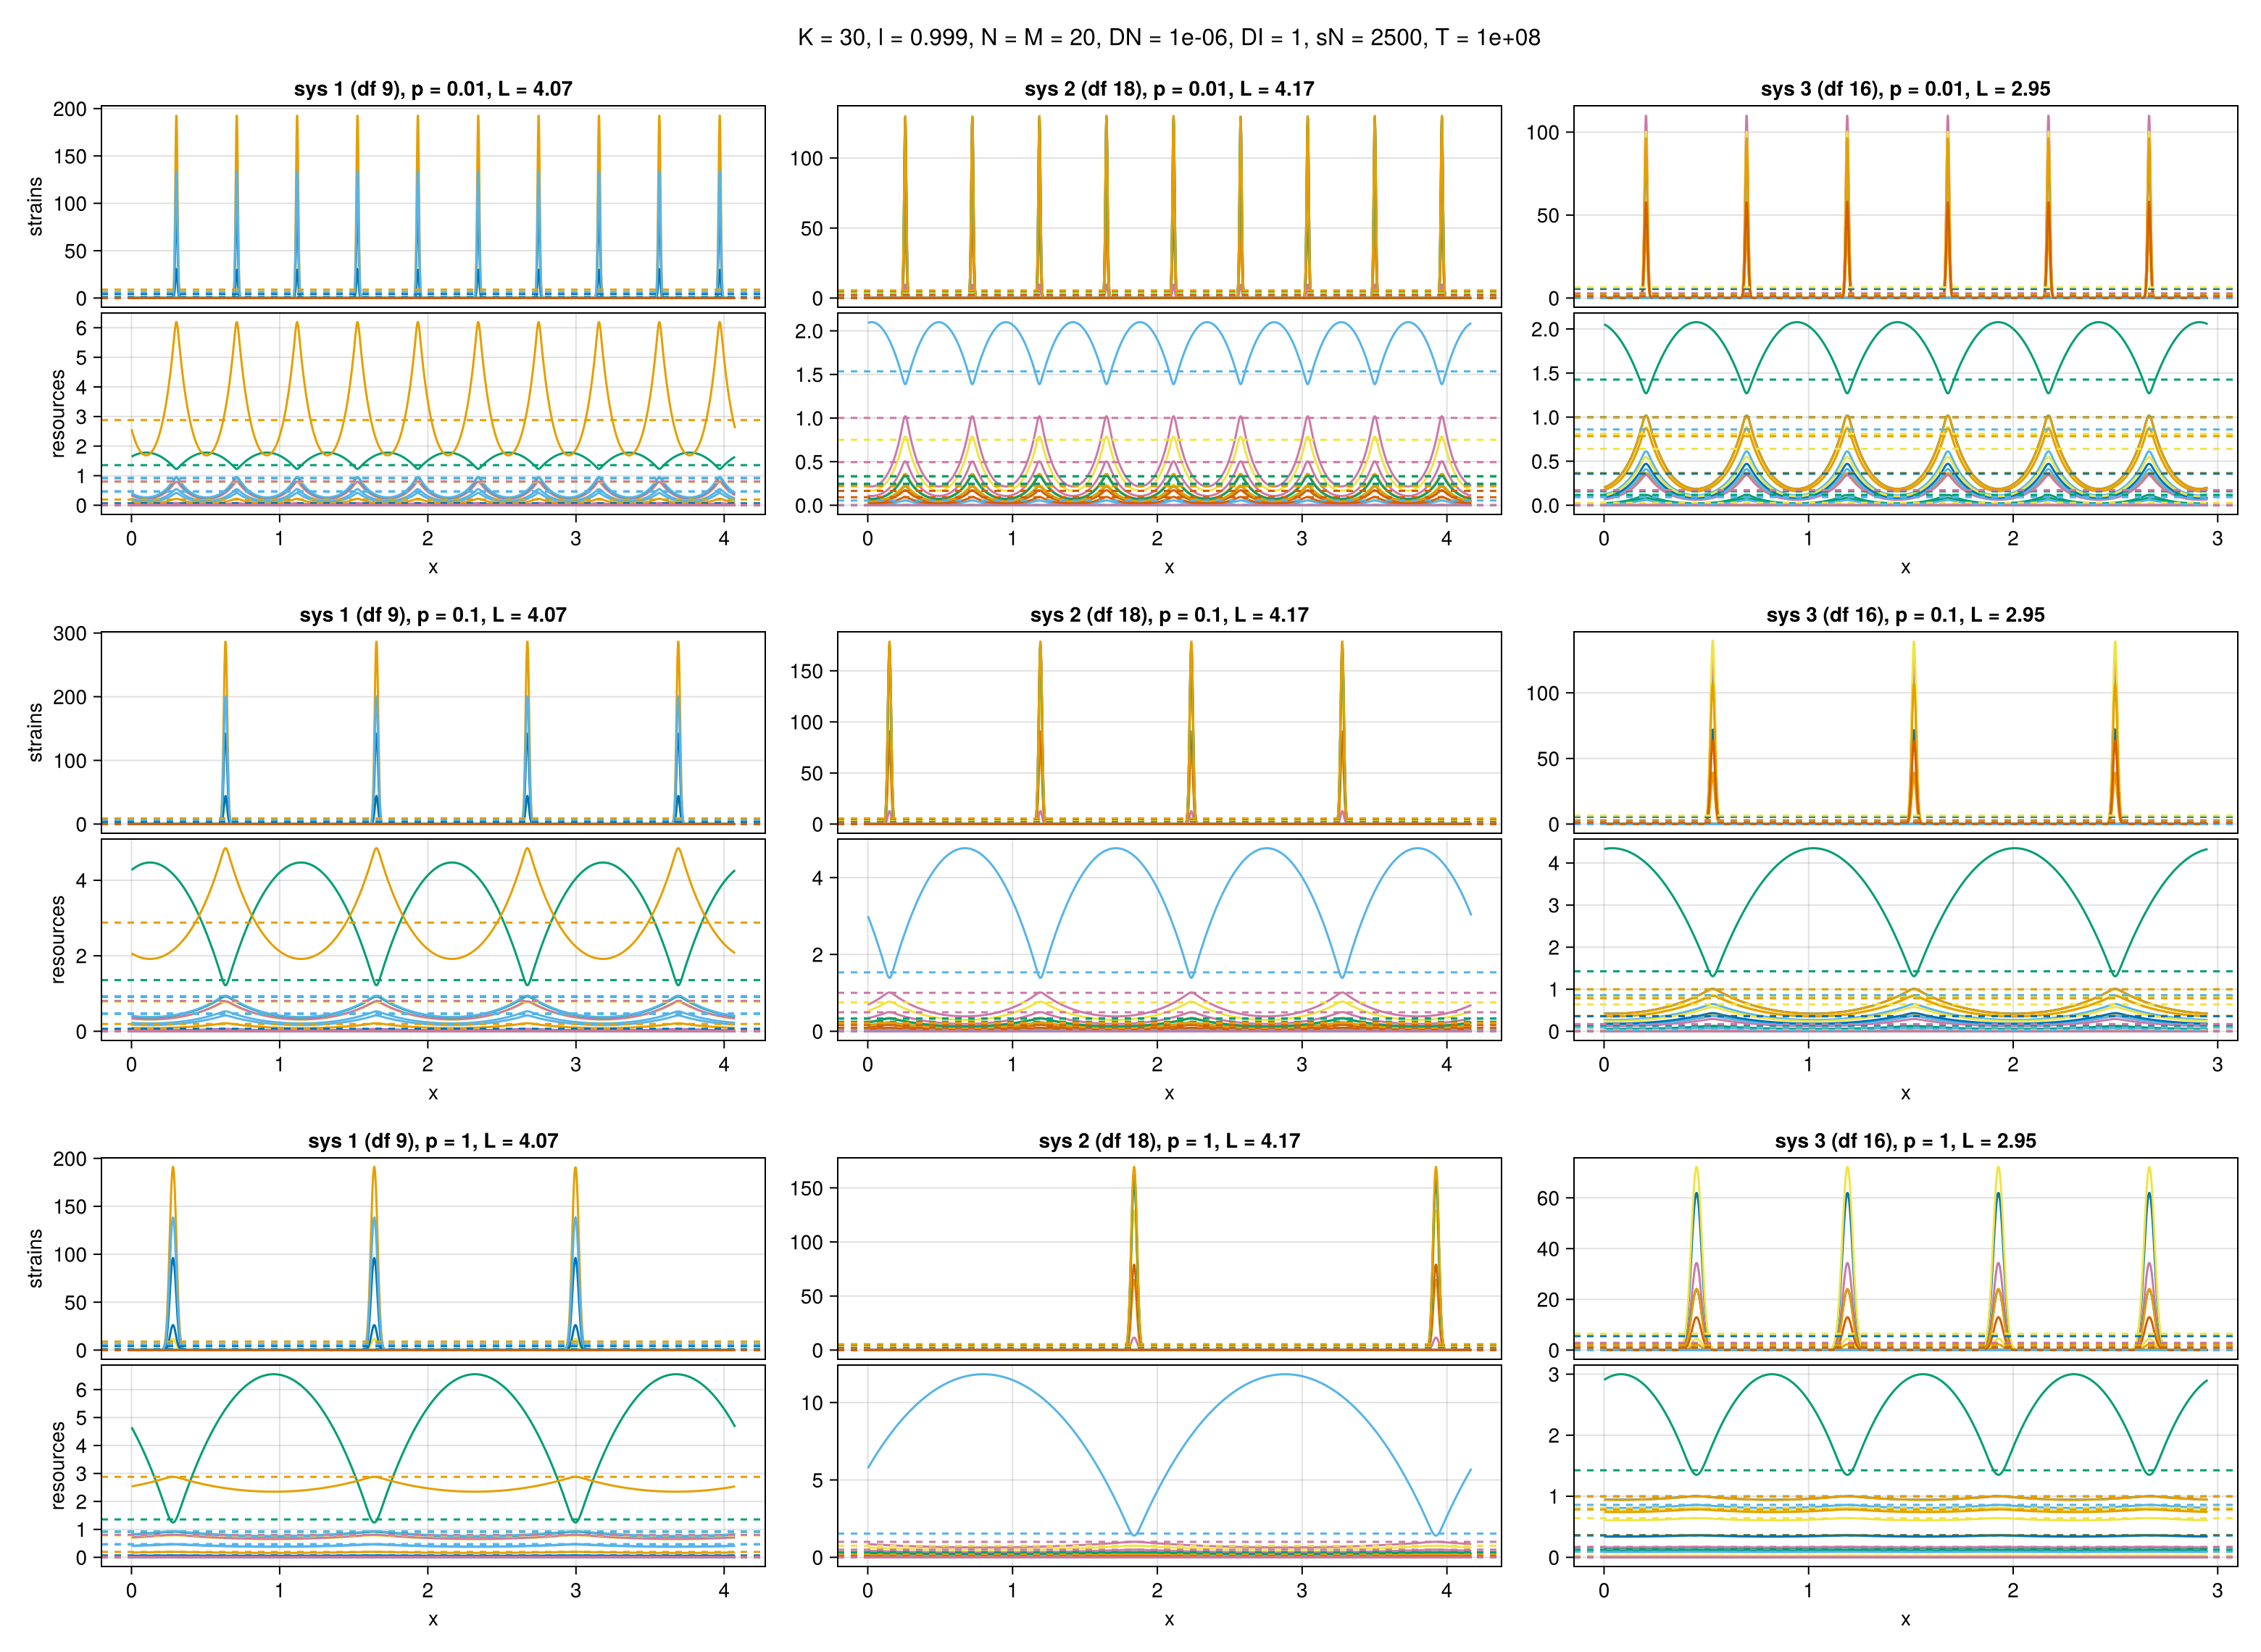

In [14]:
fig = Figure(; size=(520 * nsys, 380 * np))
Label(fig[0, 1:nsys], suptitle; fontsize=16, tellwidth=false)

for r in eachrow(df)
    i, j = panel_pos(r)
    axs, axr = plot_spatial_fs!(fig[i, j], r.final_state, Ns, r.sN, r.L / r.sN, hss_of(r))
    axs.title = short_title(r)
    axr.xlabel = "x"
    if j == 1
        axs.ylabel = "strains"
        axr.ylabel = "resources"
    end
end

Makie.save(joinpath(outdir, "final_states.pdf"), fig)
fig

## 4. Final vs homogeneous abundancesSpatial mean of the PDE final state against the well-mixed steady state, per strain and perresource. Dashed line is y = x.

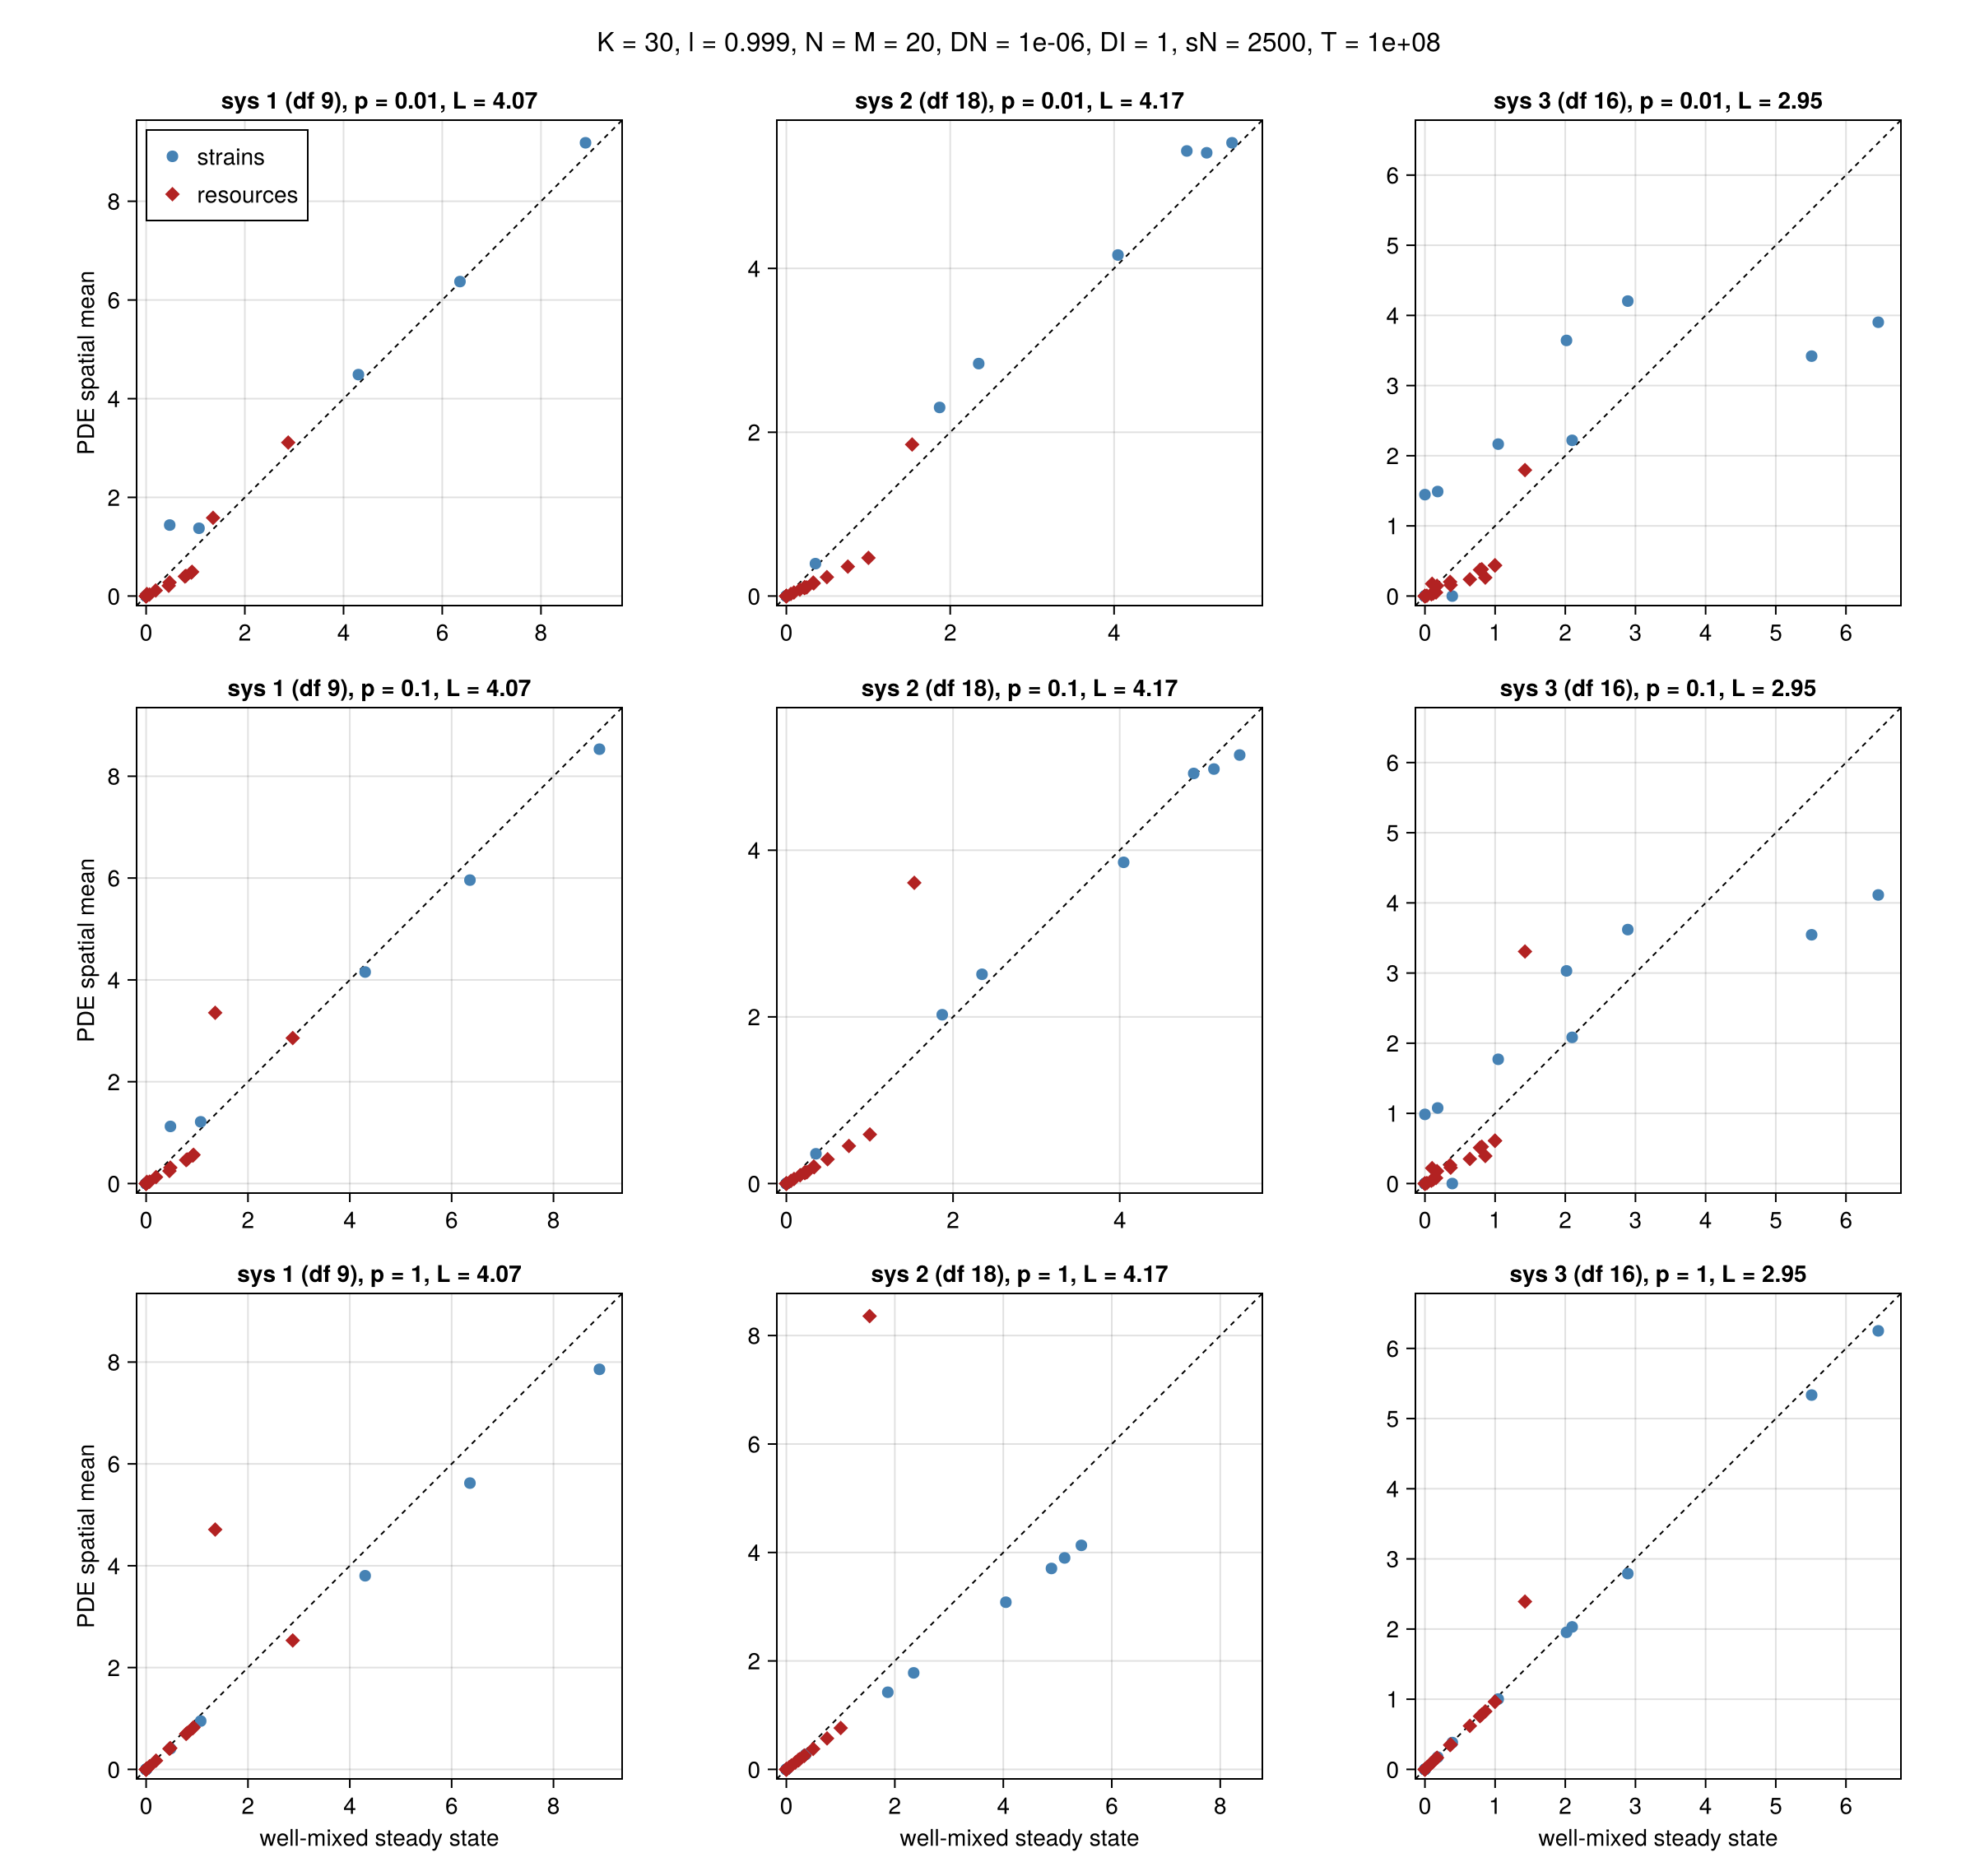

In [15]:
fig = Figure(; size=(400 * nsys, 380 * np))
Label(fig[0, 1:nsys], suptitle; fontsize=16, tellwidth=false)

for r in eachrow(df)
    i, j = panel_pos(r)
    hss = hss_of(r)
    mns = vec(mean(r.final_state, dims=2))

    ax = Axis(fig[i, j]; title=short_title(r), aspect=1,
        xlabel=(i == np ? "well-mixed steady state" : ""),
        ylabel=(j == 1 ? "PDE spatial mean" : ""))
    ablines!(ax, 0.0, 1.0; color=:black, linestyle=:dash, linewidth=1)
    scatter!(ax, hss[1:Ns], mns[1:Ns]; color=:steelblue, markersize=10, label="strains")
    scatter!(ax, hss[Ns+1:end], mns[Ns+1:end];
        color=:firebrick, marker=:diamond, markersize=10, label="resources")
    (i == 1 && j == 1) && axislegend(ax; position=:lt, framevisible=true)

    hi = 1.05 * max(maximum(hss), maximum(mns))
    limits!(ax, -0.02hi, hi, -0.02hi, hi)
end

Makie.save(joinpath(outdir, "final_vs_hom.pdf"), fig)
fig

In [16]:
# how far the spatial means moved off the well-mixed state
DataFrame(map(eachrow(df)) do r
    hss = hss_of(r)
    mns = vec(mean(r.final_state, dims=2))
    (; r.pde_df_row, sys=r.gdf_row, r.p,
        hom_biomass=sum(hss[1:Ns]),
        pde_biomass=sum(mns[1:Ns]),
        biomass_ratio=sum(mns[1:Ns]) / sum(hss[1:Ns]),
        hom_surv=count(>(1e-6), hss[1:Ns]),
        pde_surv=count(>(1e-6), mns[1:Ns]))
end)

Row,pde_df_row,sys,p,hom_biomass,pde_biomass,biomass_ratio,hom_surv,pde_surv
,Int64,Int64,Float64,Float64,Float64,Float64,Int64,Int64
1,1,1,0.01,21.1129,22.8585,1.08268,5,5
2,2,1,0.1,21.1129,20.9811,0.993757,5,5
3,3,1,1.0,21.1129,18.6412,0.882927,5,5
4,4,2,0.01,24.0783,26.076,1.08297,7,7
5,5,2,0.1,24.0783,23.7869,0.9879,7,7
6,6,2,1.0,24.0783,18.2943,0.759786,7,7
7,7,3,0.01,20.5932,22.4916,1.09218,8,8
8,8,3,0.1,20.5932,20.2276,0.982245,8,8
9,9,3,1.0,20.5932,19.9191,0.967266,8,8
